# sample

In [1]:
%load_ext autoreload

%autoreload 2


In [2]:
cd ..

/Users/alain/Desktop/master-thesis/guiding-diffusion-based-weather-models


In [3]:
from pathlib import Path 
from typing import Callable

import xarray as xr
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from geoarches.lightning_modules import load_module
from geoarches.dataloaders.era5 import Era5Forecast

In [4]:
device = "mps"
# model, config = load_module("archesweather-m-seed0")

ds = Era5Forecast(
    path="data/era5_240/full",  # default path
    domain="test", # domain to consider. domain = 'test' loads the 2020 period
    load_prev=True,  # whether to load previous state
    norm_scheme="pangu",  # default normalization scheme
    lead_time_hours=6
)

sample_state = ds[0]
gt_state = sample_state["next_state"]

X_start = {k: v[None].to(device) for k, v in sample_state.items()}

4it [00:00, 16.32it/s]

start time 2019-12-31T18:00:00


In [14]:
gen_model, gen_config = load_module("archesweathergen")
gen_model = gen_model.to(device)

Restored from modelstore/archesweather-m-seed0/checkpoints/checkpoint.ckpt
self.device cpu
Restored from modelstore/archesweathergen/checkpoints/checkpoint.ckpt


In [ ]:
# TODO: check my implementation produces the same output as the original implementation
# TODO: need to define how to pass the guidance var and partition!
# TODO: how to flow gradient through tensor_dict???
sample = gen_model.rollout_step(
    X_start, 
    y_t=torch.tensor(1, device=X_start["state"].device, dtype=torch.float32), 
    mask=torch.zeros((121, 240), device=X_start["state"].device, dtype=torch.float32)
).cpu()

  4%|▍         | 1/25 [00:09<03:44,  9.37s/it]

mps:0 mps:0 mps mps


  8%|▊         | 2/25 [00:18<03:27,  9.01s/it]

mps:0 mps:0 mps:0 mps


 12%|█▏        | 3/25 [00:26<03:15,  8.90s/it]

...

mps:0 mps:0 mps:0 mps


 96%|█████████▌| 24/25 [03:32<00:08,  8.86s/it]

mps:0 mps:0 mps:0 mps


100%|██████████| 25/25 [03:41<00:00,  8.85s/it]

mps:0 mps:0 mps:0 mps


## plot

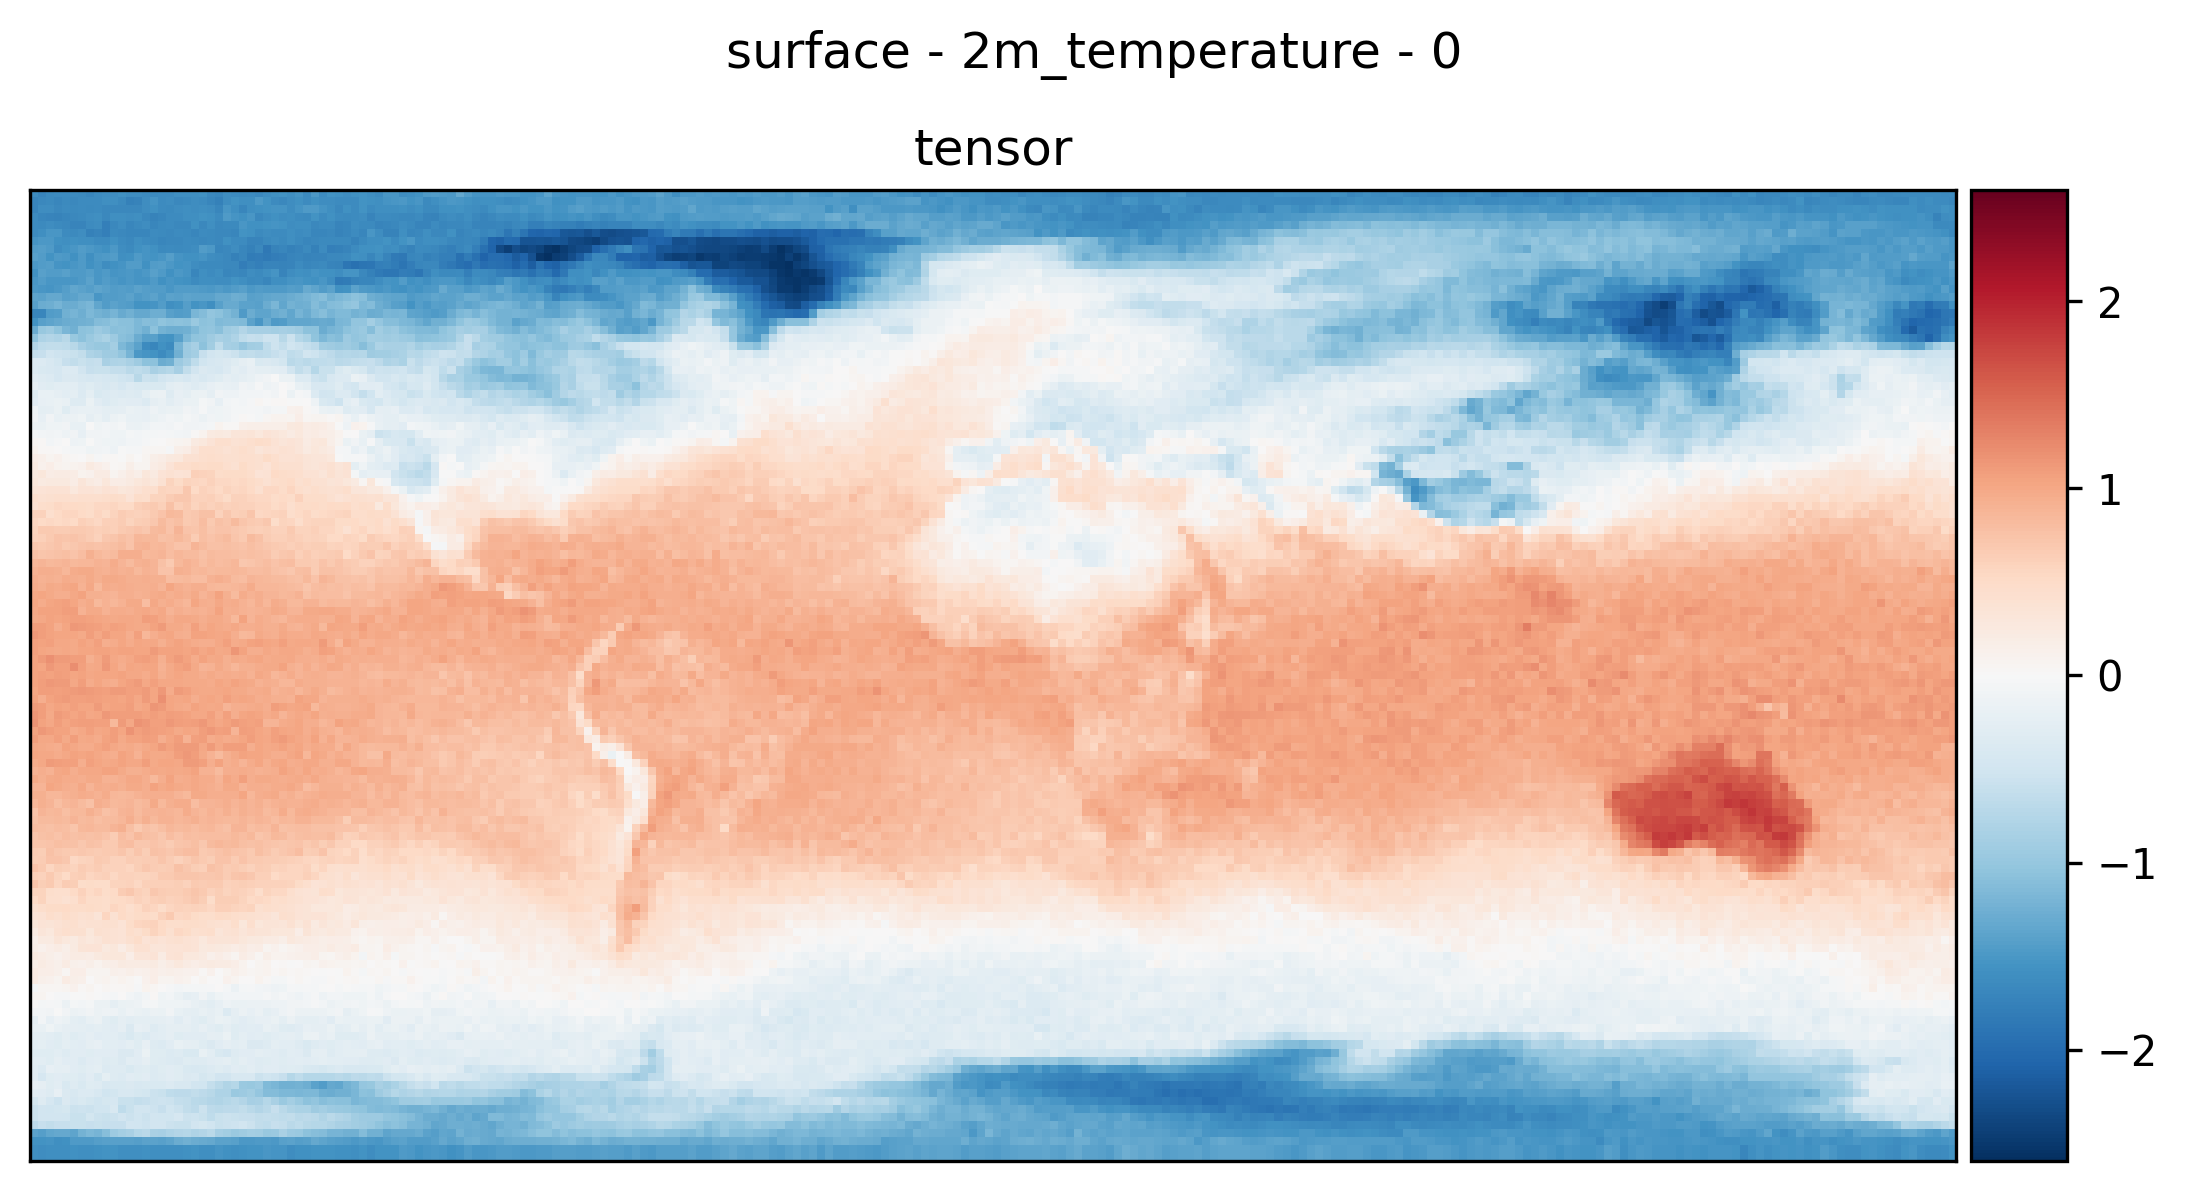

In [ ]:
VARIABLES = {
    "surface": [
        "10m_u_component_of_wind",
        "10m_v_component_of_wind",
        "2m_temperature",
        "mean_sea_level_pressure"
    ],
    "level": [
        "geopotential",
        "u_component_of_wind",
        "v_component_of_wind",
        "temperature",
        "specific_humidity",
        "vertical_velocity"
    ]
}

from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# TODO: normalize the colorbar across

def plot_sample(sample, title=""):
    sample = sample.cpu()

    fig, ax = plt.subplots(1, 1, dpi=300, figsize=(8, 4))
    fig.suptitle(title)

    vmax = sample.abs().max().item()
    if vmax == 0:
        vmax = 1e-8
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    im = ax.imshow(sample, cmap="RdBu_r", norm=norm)
    ax.set_title("tensor")
    ax.set_xticks([])
    ax.set_yticks([])

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im, cax=cax)

    plt.tight_layout()
    plt.show()
    

def plot_state(sample, partition: str, var: str, var_idx: int, level: int):
    sample = sample[var_idx, level]
    title = f"{partition} - {var} - {level}"
    plot_sample(sample, title)

partition = "surface"
var = "2m_temperature"
var_idx = VARIABLES[partition].index(var)
level = 0

# print(pred_state.shape)


plot_state(sample[partition][0], partition, var, var_idx, level)

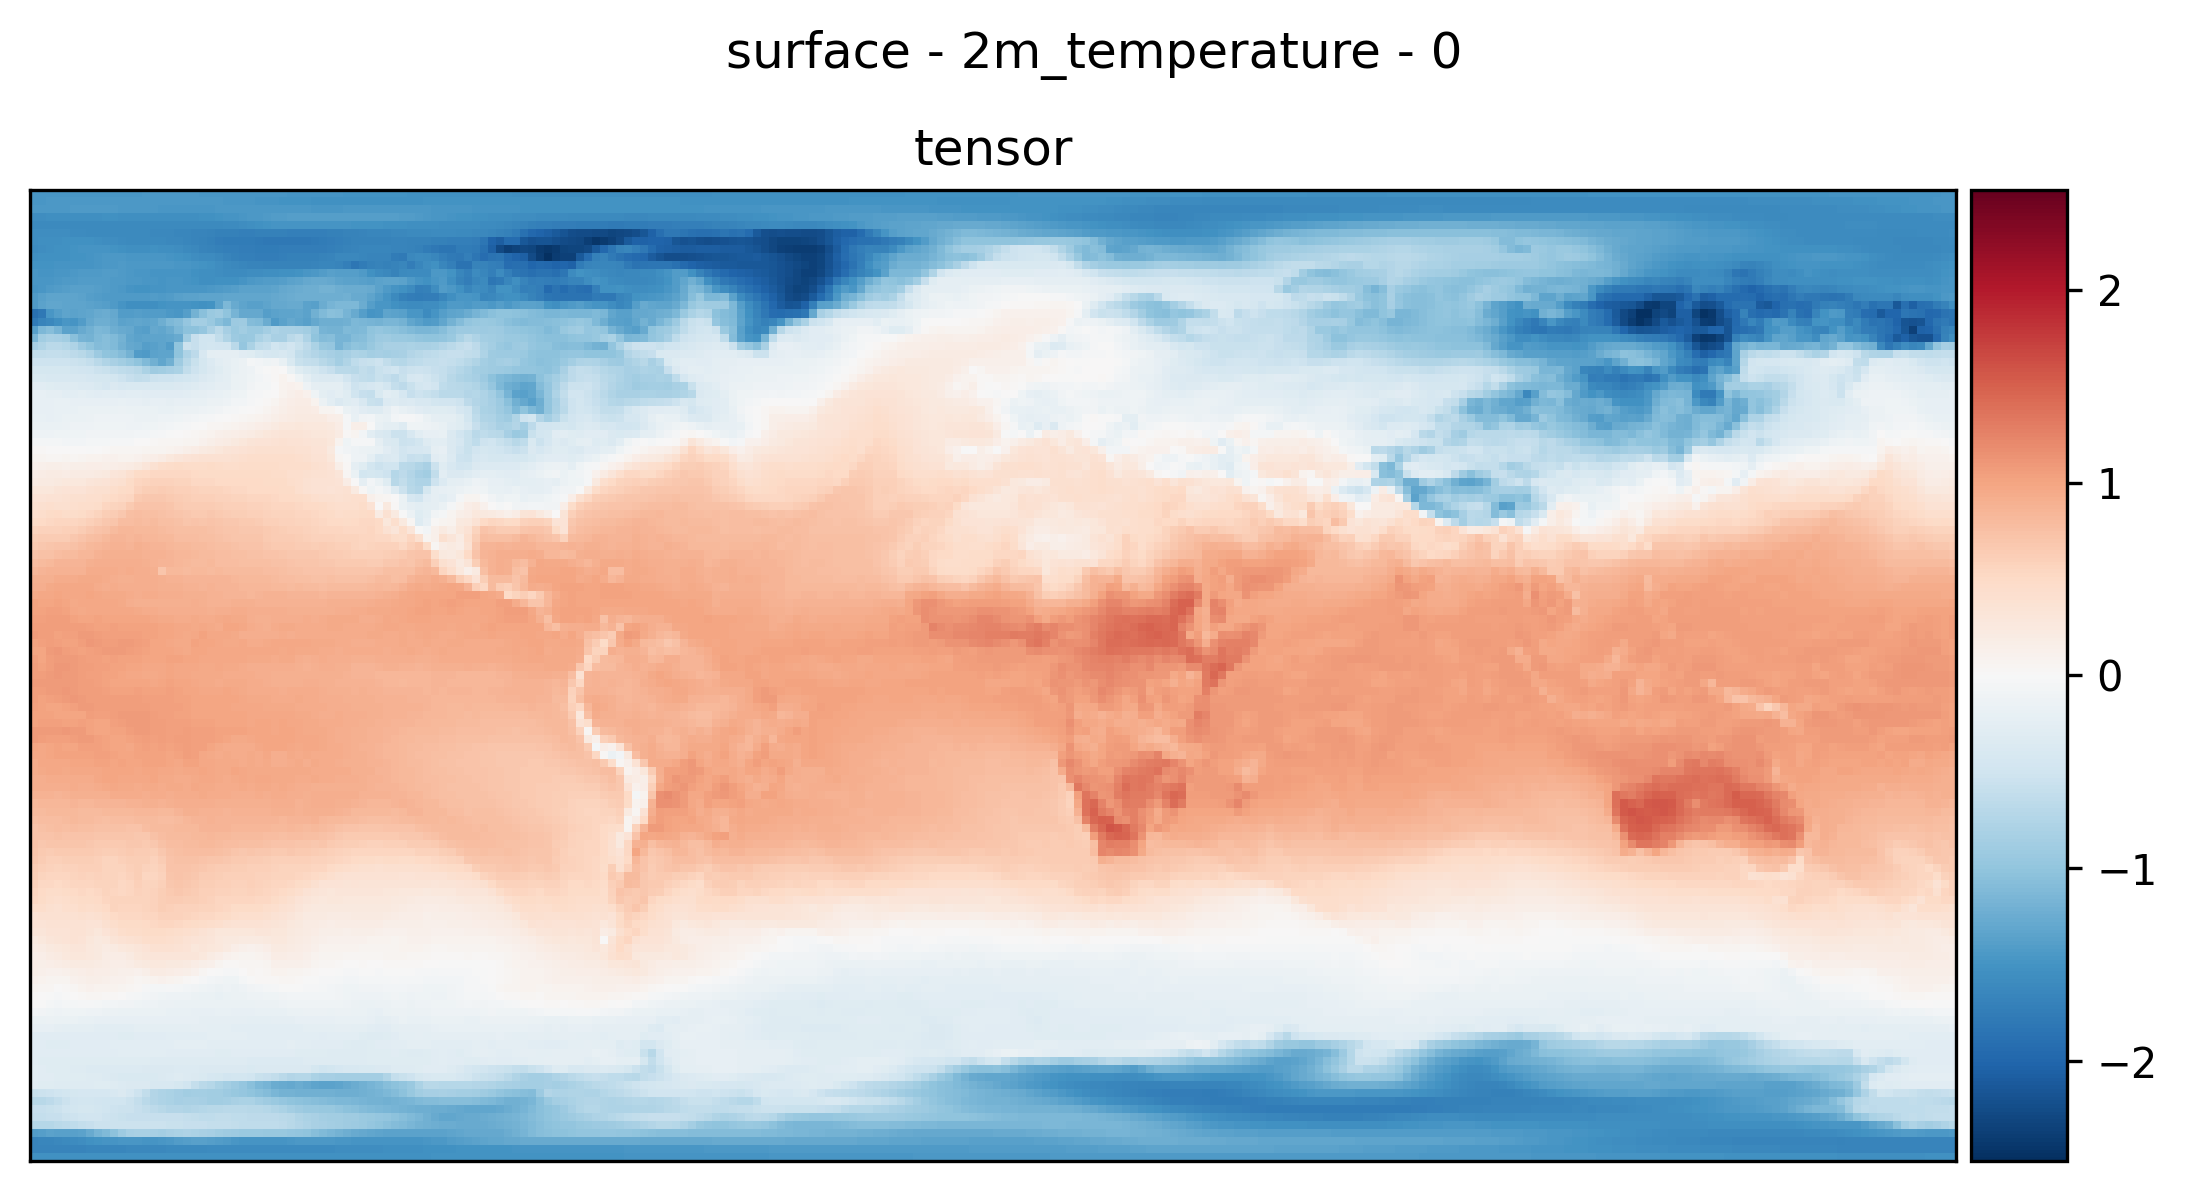

In [26]:
plot_state(gt_state[partition], partition, var, var_idx, level)

In [25]:
gt_state

TensorDict(
    fields={
        level: Tensor(shape=torch.Size([6, 13, 121, 240]), device=cpu, dtype=torch.float32, is_shared=False),
        surface: Tensor(shape=torch.Size([4, 1, 121, 240]), device=cpu, dtype=torch.float32, is_shared=False)},
    batch_size=torch.Size([]),
    device=None,
    is_shared=False)